## SETUP

In [1]:
from pathlib import Path

import pandas as pd
import tensorflow as tf
import yaml
from tensorflow.image import grayscale_to_rgb
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras.metrics import AUC, BinaryAccuracy, Precision, Recall
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
)

from breast_cancer.data import optimize_dataset, prepare_dataset
from breast_cancer.models import build_from_pretrained
from breast_cancer.utils import get_save_path
from breast_cancer.train import train_model
from breast_cancer.utils.plots import plot_history

2025-09-22 02:09:10.439430: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-22 02:09:10.601099: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-09-22 02:09:11.273108: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory
2025-09-22 02:09:11.273197: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared object file: No such file or 

In [2]:
# Check installed tensorflow version
print(f"Tensorflow version: {tf.__version__}")

# Check GPU availability
print(f"GPU List: {tf.config.list_physical_devices('GPU')}")

Tensorflow version: 2.10.1
GPU List: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [3]:
# Import general configurations
with open("../configs/default.yml") as f:
    default_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import training configurations
with open("../configs/training.yml") as f:
    training_cfg = yaml.load(f, Loader=yaml.FullLoader)

# Import model configurations
with open("../configs/model_pretrained.yml") as f:
    model_cfg = yaml.load(f, Loader=yaml.FullLoader)

In [4]:
dir_data_split = Path(default_cfg["dirs"]["data_split"])
dir_data_split.mkdir(parents=True, exist_ok=True)

dir_model_logs = Path(default_cfg["dirs"]["model_logs"])
dir_model_logs.mkdir(parents=True, exist_ok=True)

dir_model_initial = Path(default_cfg["dirs"]["model_initial"])
dir_model_initial.mkdir(parents=True, exist_ok=True)

dir_model_final = Path(default_cfg["dirs"]["model_final"])
dir_model_final.mkdir(parents=True, exist_ok=True)

In [5]:
def get_dataset(image_paths, image_labels, image_resize, dataset_cfg):
    if isinstance(image_resize, int):
        image_resize = (image_resize, image_resize)
    dataset = prepare_dataset(image_paths, image_labels, image_resize)
    dataset = optimize_dataset(dataset, **dataset_cfg)
    return dataset

In [6]:
# Set random seeds
tf.random.set_seed(default_cfg["random_seed"])

In [7]:
EPOCHS = 80

## MODEL STARTING POINT

In [8]:
from tensorflow.keras.applications import InceptionV3

# Build backbone from pretrained model
backbone = InceptionV3(**model_cfg["base_model_args"])

# Build model from spec
model = build_from_pretrained(backbone, model_cfg["model_args"])
model.summary()

# Save initial weights for multiple training configurations
save_path = get_save_path(default_cfg["dirs"]["model_initial"], f"{model.name}_{backbone.name}", "")
model.save_weights(save_path)
print(f"Model initial weights are saved at {save_path}")

2025-09-22 02:09:13.444093: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-09-22 02:09:13.562377: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1616] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22282 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:81:00.0, compute capability: 8.9


Model: "pretrained"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 256, 256, 3)]     0         
                                                                 
 inception_v3 (Functional)   (None, 6, 6, 2048)        21802784  
                                                                 
 transition_layer (GlobalAve  (None, 2048)             0         
 ragePooling2D)                                                  
                                                                 
 dense (Dense)               (None, 512)               1049088   
                                                                 
 batch_normalization_94 (Bat  (None, 512)              2048      
 chNormalization)                                                
                                                                 
 dropout (Dropout)           (None, 512)               0

## MODEL EXPLORATION

#### Split by Image ID

In [27]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random.csv")

df_train_image_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Training_P_0000...,../data/images/processed/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1,P_00007,benign,../data/images/augmented/Calc-Training_P_00007...,Calc-Training_P_00007_LEFT_CC_1-augmented-7


In [ ]:
ds_train_image_random = get_dataset(
    df_train_image_random["augmented"].values,
    df_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_image_random = get_dataset(
    df_val_image_random["processed"].values,
    df_val_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [29]:
# Load the model and freeze backbone
model.load_weights(save_path)
backbone = model.get_layer("inception_v3")
backbone.trainable = False

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [30]:
# Train head only
history_image1 = model.fit(
    ds_train_image_random,
    validation_data=ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


323/323 [==============================] - 24s 57ms/step - loss: 7.1451 - auc_2: 0.5227 - binary_accuracy: 0.5195 - precision_2: 0.4265 - recall_2: 0.4785 - val_loss: 6.4997 - val_auc_2: 0.6736 - val_binary_accuracy: 0.6353 - val_precision_2: 0.5931 - val_recall_2: 0.3644 - lr: 1.0000e-04
Epoch 2/80
323/323 [==============================] - 13s 39ms/step - loss: 6.3461 - auc_2: 0.5265 - binary_accuracy: 0.5226 - precision_2: 0.4278 - recall_2: 0.4662 - val_loss: 5.7680 - val_auc_2: 0.7054 - val_binary_accuracy: 0.6440 - val_precision_2: 0.5964 - val_recall_2: 0.4195 - lr: 1.0000e-04
Epoch 3/80
323/323 [==============================] - 13s 39ms/step - loss: 5.6314 - auc_2: 0.5262 - binary_accuracy: 0.5290 - precision_2: 0.4335 - recall_2: 0.4624 - val_loss: 5.1130 - val_auc_2: 0.7087 - val_binary_accuracy: 0.6702 - val_precision_2: 0.6536 - val_recall_2: 0.4237 - lr: 1.0000e-04
Epoch 4/80
323/323 [==============================] - 14s 42ms/step - loss: 4.9790 - auc_2: 0.5331 - binary_

In [31]:
# Unfreeze parts of the backbone for fine tuning
backbone_layers = backbone.layers
start_trainable = -int(0.2*len(backbone_layers))

for l in backbone_layers[start_trainable:]:
    l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_image2 = model.fit(
    ds_train_image_random,
    validation_data = ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
  1/323 [..............................] - ETA: 43s - loss: 0.6736 - auc_2: 0.0000e+00 - binary_accuracy: 0.4375 - precision_2: 0.0000e+00 - recall_2: 0.0000e+00

323/323 [==============================] - 13s 41ms/step - loss: 0.6249 - auc_2: 0.7492 - binary_accuracy: 0.6976 - precision_2: 0.6543 - recall_2: 0.5660 - val_loss: 0.6188 - val_auc_2: 0.7705 - val_binary_accuracy: 0.6859 - val_precision_2: 0.5972 - val_recall_2: 0.7288 - lr: 1.0000e-05
Epoch 2/80
323/323 [==============================] - 13s 41ms/step - loss: 0.6169 - auc_2: 0.7607 - binary_accuracy: 0.7050 - precision_2: 0.6640 - recall_2: 0.5767 - val_loss: 0.6208 - val_auc_2: 0.7725 - val_binary_accuracy: 0.6859 - val_precision_2: 0.6014 - val_recall_2: 0.7034 - lr: 1.0000e-05
Epoch 3/80
323/323 [==============================] - 13s 40ms/step - loss: 0.6170 - auc_2: 0.7629 - binary_accuracy: 0.7095 - precision_2: 0.6705 - recall_2: 0.5817 - val_loss: 0.6208 - val_auc_2: 0.7718 - val_binary_accuracy: 0.6841 - val_precision_2: 0.5908 - val_recall_2: 0.7585 - lr: 1.0000e-05
Epoch 4/80
323/323 [==============================] - ETA: 0s - loss: 0.6211 - auc_2: 0.7569 - binary_accura

In [32]:
# Unfreeze all layers for fine tuning
model.trainable = True

# Fine tune the model
history_image3 = model.fit(
    ds_train_image_random,
    validation_data = ds_val_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
323/323 [==============================] - 13s 40ms/step - loss: 0.5870 - auc_2: 0.8057 - binary_accuracy: 0.7418 - precision_2: 0.6945 - recall_2: 0.6680 - val_loss: 0.6221 - val_auc_2: 0.7722 - val_binary_accuracy: 0.6963 - val_precision_2: 0.6240 - val_recall_2: 0.6610 - lr: 6.8719e-07
Epoch 2/80
323/323 [==============================] - 14s 42ms/step - loss: 0.5878 - auc_2: 0.8070 - binary_accuracy: 0.7480 - precision_2: 0.7035 - recall_2: 0.6724 - val_loss: 0.6115 - val_auc_2: 0.7725 - val_binary_accuracy: 0.6963 - val_precision_2: 0.6211 - val_recall_2: 0.6737 - lr: 6.8719e-07
Epoch 3/80
323/323 [==============================] - 13s 41ms/step - loss: 0.5877 - auc_2: 0.8056 - binary_accuracy: 0.7418 - precision_2: 0.6947 - recall_2: 0.6673 - val_loss: 0.6081 - val_auc_2: 0.7726 - val_binary_accuracy: 0.6963 - val_precision_2: 0.6220 - val_recall_2: 0.6695 - lr: 6.8719e-07
Epoch 4/80
323/323 [==============================] - 13s 40ms/step - loss: 0.5880 - auc_2: 0.811

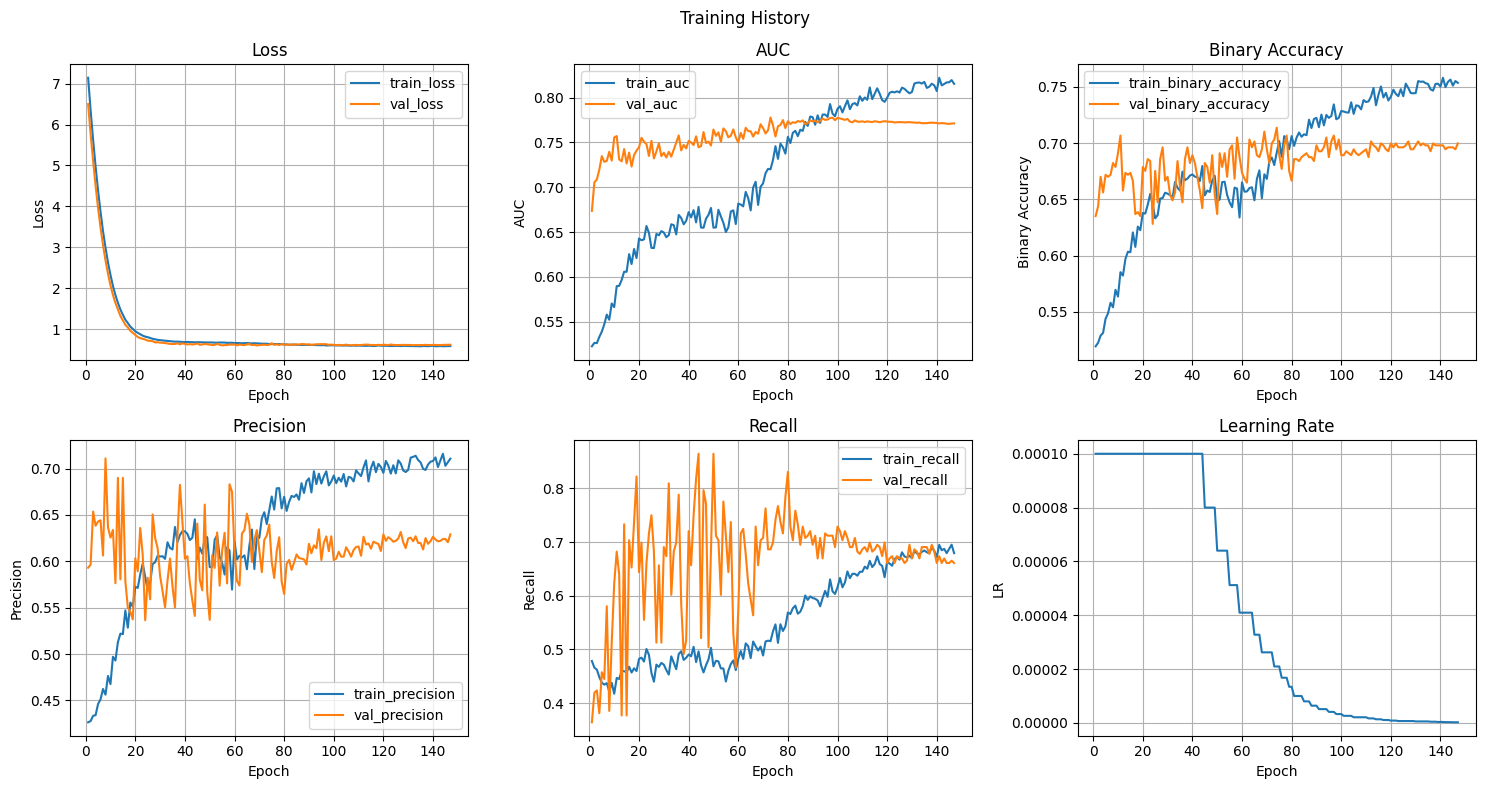

In [33]:
def append_histories(*histories):
    import re
    merged = {}
    for h in histories:
        for k, v in h.history.items():
            new_k = re.sub(r'_\d+$', '', k)
            merged.setdefault(new_k, []).extend(v)
    return merged

all_histories = append_histories(history_image1, history_image2, history_image3)

plot_history(all_histories)

In [34]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone.name}_image_random.csv")
Path(logger_path).parent.mkdir(exist_ok=True)

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/pretrained/initial_pretrained_inception_v3_image_random.csv'

#### Split by Patient ID

In [17]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random.csv")

df_train_patient_random.head(3)

,Unnamed: 0,raw,processed,imageID,patientID,label,augmented,augmentID
0,0,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-9
1,1,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-8
2,2,../data/images/raw/benign/Calc-Test_P_00038_LE...,../data/images/processed/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1,P_00038,benign,../data/images/augmented/Calc-Test_P_00038_LEF...,Calc-Test_P_00038_LEFT_CC_1-augmented-7


In [18]:
ds_train_patient_random = get_dataset(
    df_train_patient_random["augmented"].values,
    df_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_val_patient_random = get_dataset(
    df_val_patient_random["processed"].values,
    df_val_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["test"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [19]:
# Load the model and freeze backbone
model.load_weights(save_path)
backbone = model.get_layer("inception_v3")
backbone.trainable = False

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["initial_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="val_loss", **training_cfg["initial_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="val_loss", **training_cfg["initial_training"]["reduce_on_plateau"])

In [20]:
# Train head only
history_patient1 = model.fit(
    ds_train_patient_random,
    validation_data=ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80


2025-09-22 02:39:12.060564: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:390] Filling up shuffle buffer (this may take a while): 447 of 5000
2025-09-22 02:39:21.526819: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:390] Filling up shuffle buffer (this may take a while): 1072 of 5000
2025-09-22 02:39:32.255055: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:390] Filling up shuffle buffer (this may take a while): 1737 of 5000
2025-09-22 02:39:41.488846: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:390] Filling up shuffle buffer (this may take a while): 2453 of 5000
2025-09-22 02:40:14.227403: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:390] Filling up shuffle buffer (this may take a while): 2706 of 5000
2025-09-22 02:40:14.227475: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:390] Filling up shuffle buffer (this may take a while): 2707 of 5000
2025-09-22 02:40:14.227497: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:390] Filling up shuf

  1/316 [..............................] - ETA: 14:27:29 - loss: 7.6280 - auc_1: 0.0000e+00 - binary_accuracy: 0.6250 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00

2025-09-22 02:41:42.749397: I tensorflow/core/kernels/data/shuffle_dataset_op.cc:415] Shuffle buffer filled.


316/316 [==============================] - 182s 53ms/step - loss: 7.1565 - auc_1: 0.5274 - binary_accuracy: 0.5245 - precision_1: 0.4233 - recall_1: 0.4865 - val_loss: 6.5610 - val_auc_1: 0.6046 - val_binary_accuracy: 0.5746 - val_precision_1: 0.4481 - val_recall_1: 0.3255 - lr: 1.0000e-04
Epoch 2/80
316/316 [==============================] - 13s 42ms/step - loss: 6.3955 - auc_1: 0.5214 - binary_accuracy: 0.5251 - precision_1: 0.4221 - recall_1: 0.4736 - val_loss: 5.8624 - val_auc_1: 0.6467 - val_binary_accuracy: 0.6175 - val_precision_1: 0.5187 - val_recall_1: 0.4575 - lr: 1.0000e-04
Epoch 3/80
316/316 [==============================] - 13s 40ms/step - loss: 5.6944 - auc_1: 0.5270 - binary_accuracy: 0.5295 - precision_1: 0.4225 - recall_1: 0.4465 - val_loss: 5.2119 - val_auc_1: 0.6641 - val_binary_accuracy: 0.6287 - val_precision_1: 0.5448 - val_recall_1: 0.3726 - lr: 1.0000e-04
Epoch 4/80
316/316 [==============================] - 13s 39ms/step - loss: 5.0672 - auc_1: 0.5260 - binary

In [21]:
# Unfreeze parts of the backbone for fine tuning
backbone_layers = backbone.layers
start_trainable = -int(0.2*len(backbone_layers))

for l in backbone_layers[start_trainable:]:
    l.trainable = True

# Set new learning rate
tf.keras.backend.set_value(model.optimizer.lr, 1e-5)

# Fine tune head and last 20% backbone layers
history_patient2 = model.fit(
    ds_train_patient_random,
    validation_data = ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
  2/316 [..............................] - ETA: 18s - loss: 0.6509 - auc_1: 0.0000e+00 - binary_accuracy: 0.4688 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00

316/316 [==============================] - 13s 42ms/step - loss: 0.6513 - auc_1: 0.6678 - binary_accuracy: 0.6335 - precision_1: 0.5550 - recall_1: 0.4709 - val_loss: 0.6181 - val_auc_1: 0.7234 - val_binary_accuracy: 0.6455 - val_precision_1: 0.5374 - val_recall_1: 0.7453 - lr: 1.0000e-05
Epoch 2/80
316/316 [==============================] - 13s 40ms/step - loss: 0.6433 - auc_1: 0.6884 - binary_accuracy: 0.6495 - precision_1: 0.5827 - recall_1: 0.4683 - val_loss: 0.6150 - val_auc_1: 0.7235 - val_binary_accuracy: 0.6623 - val_precision_1: 0.5585 - val_recall_1: 0.6981 - lr: 1.0000e-05
Epoch 3/80
316/316 [==============================] - 13s 41ms/step - loss: 0.6390 - auc_1: 0.6981 - binary_accuracy: 0.6589 - precision_1: 0.5965 - recall_1: 0.4826 - val_loss: 0.6182 - val_auc_1: 0.7196 - val_binary_accuracy: 0.6623 - val_precision_1: 0.5665 - val_recall_1: 0.6226 - lr: 1.0000e-05
Epoch 4/80
316/316 [==============================] - 13s 41ms/step - loss: 0.6380 - auc_1: 0.6993 - binary_

In [22]:
# Unfreeze all layers for fine tuning
model.trainable = True

# Fine tune the model
history_patient3 = model.fit(
    ds_train_patient_random,
    validation_data = ds_val_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=EPOCHS,
)

Epoch 1/80
  1/316 [..............................] - ETA: 37s - loss: 0.5333 - auc_1: 0.0000e+00 - binary_accuracy: 0.7969 - precision_1: 0.0000e+00 - recall_1: 0.0000e+00

316/316 [==============================] - 13s 42ms/step - loss: 0.6139 - auc_1: 0.7385 - binary_accuracy: 0.6896 - precision_1: 0.6315 - recall_1: 0.5576 - val_loss: 0.6171 - val_auc_1: 0.7284 - val_binary_accuracy: 0.6567 - val_precision_1: 0.5648 - val_recall_1: 0.5755 - lr: 1.6777e-06
Epoch 2/80
316/316 [==============================] - 13s 40ms/step - loss: 0.6109 - auc_1: 0.7426 - binary_accuracy: 0.6914 - precision_1: 0.6355 - recall_1: 0.5546 - val_loss: 0.6177 - val_auc_1: 0.7303 - val_binary_accuracy: 0.6679 - val_precision_1: 0.5794 - val_recall_1: 0.5849 - lr: 1.6777e-06
Epoch 3/80
316/316 [==============================] - 13s 41ms/step - loss: 0.6097 - auc_1: 0.7458 - binary_accuracy: 0.6946 - precision_1: 0.6405 - recall_1: 0.5575 - val_loss: 0.6156 - val_auc_1: 0.7306 - val_binary_accuracy: 0.6623 - val_precision_1: 0.5701 - val_recall_1: 0.5943 - lr: 1.6777e-06
Epoch 4/80
316/316 [==============================] - 13s 40ms/step - loss: 0.6151 - auc_1: 0.7389 - binary_

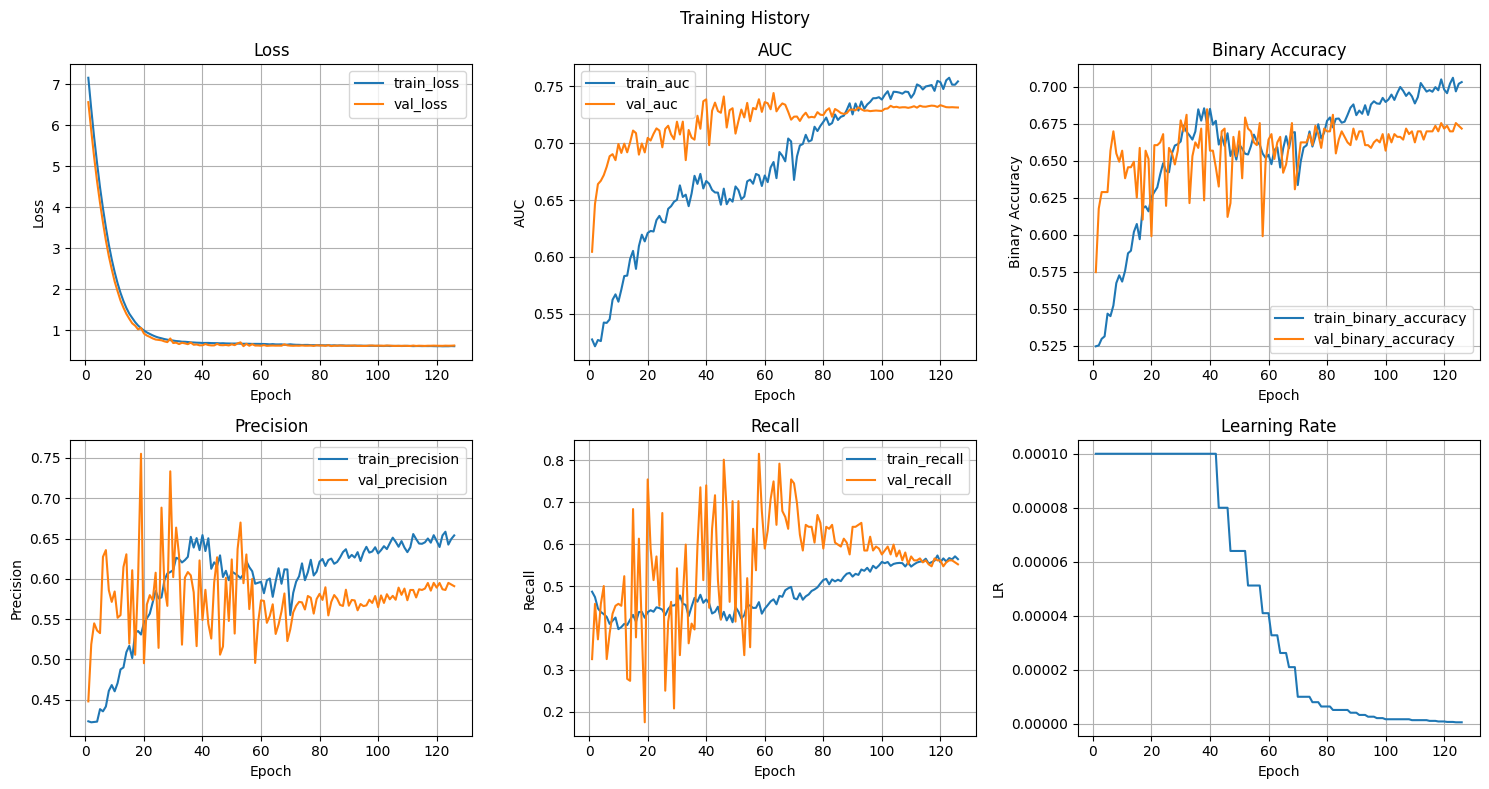

In [23]:
all_histories = append_histories(history_patient1, history_patient2, history_patient3)

plot_history(all_histories)

In [24]:
logger_path = str(dir_model_logs/model.name/f"initial_{model.name}_{backbone.name}_patient_random.csv")

pd.DataFrame(all_histories).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/pretrained/initial_pretrained_inception_v3_patient_random.csv'

## FINAL EVALUATION

#### Split by Image ID

In [9]:
df_train_image_random = pd.read_csv(dir_data_split / "train_image_random_aug.csv") # get the augmented version
df_val_image_random = pd.read_csv(dir_data_split / "val_image_random_aug.csv") # get the augmented version

# Combine train and val data for full training
df_full_train_image_random = pd.concat([df_train_image_random, df_val_image_random], ignore_index=True)

ds_full_train_image_random = get_dataset(
    df_full_train_image_random["augmented"].values,
    df_full_train_image_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [10]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["final_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="loss", **training_cfg["final_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="loss", **training_cfg["final_training"]["reduce_on_plateau"])

In [11]:
# Train model
history_image_full = model.fit(
    ds_full_train_image_random,
    callbacks=[early_stop, lr_reducer],
    epochs=75, # when model start to overfit during experiments
)

Epoch 1/75


2025-09-21 14:35:18.040305: I tensorflow/stream_executor/cuda/cuda_dnn.cc:384] Loaded cuDNN version 8905
2025-09-21 14:35:18.071940: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 14:35:18.075739: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 14:35:18.075757: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2025-09-21 14:35:18.076180: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2025-09-21 14:35:18.076222: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas location.
This message will be only logged once.
2025-09-21 14:35:18.148840: I tensorflow/stream_executor/cuda/c

403/403 [==============================] - 20s 40ms/step - loss: 7.0431 - auc: 0.5472 - binary_accuracy: 0.5331 - precision: 0.4439 - recall: 0.5228 - lr: 1.0000e-04
Epoch 2/75
403/403 [==============================] - 12s 29ms/step - loss: 6.0942 - auc: 0.5581 - binary_accuracy: 0.5480 - precision: 0.4564 - recall: 0.5043 - lr: 1.0000e-04
Epoch 3/75
403/403 [==============================] - 11s 28ms/step - loss: 5.2702 - auc: 0.5655 - binary_accuracy: 0.5536 - precision: 0.4607 - recall: 0.4839 - lr: 1.0000e-04
Epoch 4/75
403/403 [==============================] - 12s 28ms/step - loss: 4.5322 - auc: 0.5744 - binary_accuracy: 0.5602 - precision: 0.4674 - recall: 0.4781 - lr: 1.0000e-04
Epoch 5/75
403/403 [==============================] - 12s 28ms/step - loss: 3.8807 - auc: 0.5930 - binary_accuracy: 0.5760 - precision: 0.4860 - recall: 0.4932 - lr: 1.0000e-04
Epoch 6/75
403/403 [==============================] - 12s 28ms/step - loss: 3.3093 - auc: 0.6112 - binary_accuracy: 0.5873 - p

In [12]:
# Save final model
model.save(dir_model_final/model.name/f"{model.name}_{backbone.name}_image_random.h5")

In [13]:
#Export final training history
logger_path = str(dir_model_logs/model.name/f"full_{model.name}_{backbone.name}_image_random.csv")

pd.DataFrame(history_image_full.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/pretrained/full_pretrained_inception_v3_image_random.csv'

In [14]:
# Setup testing data for evaluation
df_test_image_random = pd.read_csv(dir_data_split / "test_image_random.csv")

ds_test_image_random = prepare_dataset( # use prepare dataset, only converting path to image and get labels
    df_test_image_random["processed"].values,
    df_test_image_random["label"].values,
    image_resize=(default_cfg["image_resize"], default_cfg["image_resize"])
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_test_image_random = ds_test_image_random.batch(64)

In [15]:
# Final evaluation
model.evaluate(ds_test_image_random)

11/11 [==============================] - 1s 26ms/step - loss: 0.6441 - auc: 0.7179 - binary_accuracy: 0.6449 - precision: 0.5385 - recall: 0.6594 


[0.6440561413764954,
 0.7178526520729065,
 0.6448863744735718,
 0.5384615659713745,
 0.6594203114509583]

#### Split by Patient ID

In [16]:
df_train_patient_random = pd.read_csv(dir_data_split / "train_patient_random_aug.csv") # get the augmented version
df_val_patient_random = pd.read_csv(dir_data_split / "val_patient_random_aug.csv") # get the augmented version

# Combine train and val data for full training
df_full_train_patient_random = pd.concat([df_train_patient_random, df_val_patient_random], ignore_index=True)

ds_full_train_patient_random = get_dataset(
    df_full_train_patient_random["augmented"].values,
    df_full_train_patient_random["label"].values,
    image_resize=default_cfg["image_resize"],
    dataset_cfg=training_cfg["dataset"]["train"],
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

In [17]:
# Load the model initial weights
model.load_weights(save_path)

# Compile model with optimizer, loss, and metrics
optimizer = Adam(learning_rate=training_cfg["final_training"]["lr"])
loss = BinaryCrossentropy()
metrics = [AUC(), BinaryAccuracy(), Precision(), Recall()]

model.compile(optimizer=optimizer, loss=loss, metrics=metrics)

# Setup callbacks
early_stop = EarlyStopping(monitor="loss", **training_cfg["final_training"]["early_stopping"])
lr_reducer = ReduceLROnPlateau(monitor="loss", **training_cfg["final_training"]["reduce_on_plateau"])

In [18]:
# Train model
history_patient_full = model.fit(
    ds_full_train_patient_random,
    callbacks=[early_stop, lr_reducer],
    epochs=75, # when model start to overfit during experiments
)

Epoch 1/75
392/392 [==============================] - 20s 37ms/step - loss: 7.0589 - auc_1: 0.5474 - binary_accuracy: 0.5353 - precision_1: 0.4347 - recall_1: 0.5128 - lr: 1.0000e-04
Epoch 2/75
392/392 [==============================] - 11s 29ms/step - loss: 6.1426 - auc_1: 0.5508 - binary_accuracy: 0.5443 - precision_1: 0.4409 - recall_1: 0.4925 - lr: 1.0000e-04
Epoch 3/75
392/392 [==============================] - 12s 29ms/step - loss: 5.3241 - auc_1: 0.5593 - binary_accuracy: 0.5516 - precision_1: 0.4466 - recall_1: 0.4752 - lr: 1.0000e-04
Epoch 4/75
392/392 [==============================] - 11s 28ms/step - loss: 4.5912 - auc_1: 0.5668 - binary_accuracy: 0.5589 - precision_1: 0.4536 - recall_1: 0.4679 - lr: 1.0000e-04
Epoch 5/75
392/392 [==============================] - 12s 29ms/step - loss: 3.9408 - auc_1: 0.5756 - binary_accuracy: 0.5689 - precision_1: 0.4642 - recall_1: 0.4592 - lr: 1.0000e-04
Epoch 6/75
392/392 [==============================] - 11s 29ms/step - loss: 3.3759 - 

In [19]:
# Save final model
model.save(dir_model_final/model.name/f"{model.name}_{backbone.name}_patient_random.h5")

In [20]:
#Export final training history
logger_path = str(dir_model_logs/model.name/f"full_{model.name}_{backbone.name}_patient_random.csv")

pd.DataFrame(history_patient_full.history).to_csv(logger_path)

f"Saved at {logger_path}"

'Saved at ../models/logs/pretrained/full_pretrained_inception_v3_patient_random.csv'

In [21]:
# Setup testing data for evaluation
df_test_patient_random = pd.read_csv(dir_data_split / "test_patient_random.csv")

ds_test_patient_random = prepare_dataset( # use prepare dataset, only converting path to image and get labels
    df_test_patient_random["processed"].values,
    df_test_patient_random["label"].values,
    image_resize=(default_cfg["image_resize"], default_cfg["image_resize"])
).map(lambda x, y: (grayscale_to_rgb(x), y)) # convert to 3-channel images

ds_test_patient_random = ds_test_patient_random.batch(64)

In [22]:
# Final evaluation
model.evaluate(ds_test_patient_random)

13/13 [==============================] - 1s 28ms/step - loss: 0.6355 - auc_1: 0.7662 - binary_accuracy: 0.6743 - precision_1: 0.6020 - recall_1: 0.7092 


[0.6355143189430237,
 0.7661536335945129,
 0.6743002533912659,
 0.6020151376724243,
 0.7091988325119019]